In [87]:
import numpy as np
import pandas as pd

## 1. Veri Setinin Yüklenmesi

NASA C-MAPSS FD001 veri setinin eğitim, test ve gerçek RUL dosyaları Pandas kullanılarak yüklenmiştir.

* `train_FD001.txt`: Eğitim verisi
* `test_FD001.txt`: Test verisi
* `RUL_FD001.txt`: Test motorlarının son gözlemlerindeki gerçek RUL değerleri

Veriler henüz sütun isimleri atanmış veya işlenmiş değildir; sonraki adımlarda veri yapısı hazırlanacaktır.


In [88]:
df_train = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df_test = pd.read_csv("test_FD001.txt", sep="\s+", header=None)
df_rul = pd.read_csv("RUL_FD001.txt", sep="\s+", header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5842/162218881.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
/tmp/ipykernel_5842/162218881.py:2: SyntaxWarning: invalid escape sequence '\s'
  df_test = pd.read_csv("test_FD001.txt", sep="\s+", header=None)
/tmp/ipykernel_5842/162218881.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_rul = pd.read_csv("RUL_FD001.txt", sep="\s+", header=None)


## 2. Sütun İsimlerinin Tanımlanması

C-MAPSS veri dosyaları sütun isimleri olmadan geldiği için eğitim ve test verilerine anlamlı sütun isimleri atıyoruz.

Veri yapısında:

* `unit_number`: Motorun kimlik numarası
* `time_in_cycles`: Motorun çalıştığı cycle sayısı
* `op_setting_1–3`: Operasyon koşulları
* `sensor_1–21`: Sensör ölçümleri

Ayrıca `RUL_FD001.txt` dosyasındaki tek sütuna `RUL` adını veriyoruz.

Bu isimlendirme, sonraki EDA, feature engineering ve modelleme adımlarında değişkenleri daha anlaşılır şekilde kullanmamızı sağlıyor.


In [89]:
column_names = ["unit_number", "time_in_cycles", 
                "op_setting_1", "op_setting_2", "op_setting_3"] + \
               [f"sensor_{i}" for i in range(1, 22)]

df_train.columns = column_names
df_test.columns = column_names
df_rul.columns = ["RUL"]

In [90]:
print("Toplam satır sayısı:", df_train.shape[0])
print("Kaç farklı motor var:", df_train["unit_number"].nunique())

df_train.groupby("unit_number")["time_in_cycles"].max().describe()

Toplam satır sayısı: 20631
Kaç farklı motor var: 100


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

In [91]:
max_cycles = df_train.groupby("unit_number")["time_in_cycles"].max().reset_index()
max_cycles.columns = ["unit_number", "max_cycle"]

## 3. RUL Hedef Değişkeninin Oluşturulması

Her motorun eğitim verisindeki son cycle değerini kullanarak gerçek kalan ömrü (**Remaining Useful Life — RUL**) hesaplıyoruz.

Bir motor için:

`RUL = maksimum cycle - mevcut cycle`

şeklinde tanımlanır.

Örneğin bir motor 200. cycle'da sonlanıyorsa, 50. cycle'daki gözlemin RUL değeri:

`200 - 50 = 150`

olur.

Bu şekilde her eğitim gözlemine modelin tahmin edeceği `RUL` hedef değişkenini oluşturuyoruz.

Ardından RUL değerlerinin doğru şekilde oluştuğunu kontrol etmek için ilk ve son gözlemleri inceliyor, sensörlerin temel istatistiklerini `describe()` ile gözlemliyoruz.

In [92]:
df_train = df_train.merge(max_cycles, on="unit_number", how="left")
df_train["RUL"] = df_train["max_cycle"] - df_train["time_in_cycles"]

In [93]:
df_train[["unit_number", "time_in_cycles", "max_cycle", "RUL"]].head(10)

,unit_number,time_in_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [94]:
df_train[["unit_number", "time_in_cycles", "max_cycle", "RUL"]].tail(10)

,unit_number,time_in_cycles,max_cycle,RUL
20621,100,191,200,9
20622,100,192,200,8
20623,100,193,200,7
20624,100,194,200,6
20625,100,195,200,5
20626,100,196,200,4
20627,100,197,200,3
20628,100,198,200,2
20629,100,199,200,1
20630,100,200,200,0


In [95]:
df_train[[f"sensor_{i}" for i in range(1, 22)]].describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## 4. Sabit Sensörlerin Kaldırılması

Ön inceleme sonucunda bazı sensörlerin tüm gözlemler boyunca sabit veya bilgi taşımayacak düzeyde değişmediği görüldü.

Bu sensörleri modelden çıkartıyoruz çünkü değişkenlik göstermeyen özellikler modele yeni bilgi sağlamaz ve feature sayısını gereksiz yere artırır.

Kaldırılan sensörler:

`sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`

Bu karar proje kapsamında **ADR-001** ile ayrıca belgelenmiştir.

In [96]:
constant_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", 
                     "sensor_16", "sensor_18", "sensor_19"]

df_train = df_train.drop(columns=constant_sensors)
df_test = df_test.drop(columns=constant_sensors)

df_train.shape

(20631, 21)

## 5. Sensör Davranışının Görselleştirilmesi

Sensörlerin zaman içerisindeki davranışlarını incelemek için örnek olarak Motor 1'in `sensor_2` değerini cycle boyunca görselleştiriyoruz.

Bu incelemenin amacı sensörlerde:

* zamanla artan veya azalan trendleri,
* ani değişimleri,
* gürültüyü,
* potansiyel bozulma davranışlarını

gözlemlemektir.

Bu tür gözlemler, daha sonra gerçekleştireceğimiz **rolling mean, rolling standard deviation ve trend feature engineering** adımlarının neden gerekli olduğunu anlamamıza yardımcı olur.


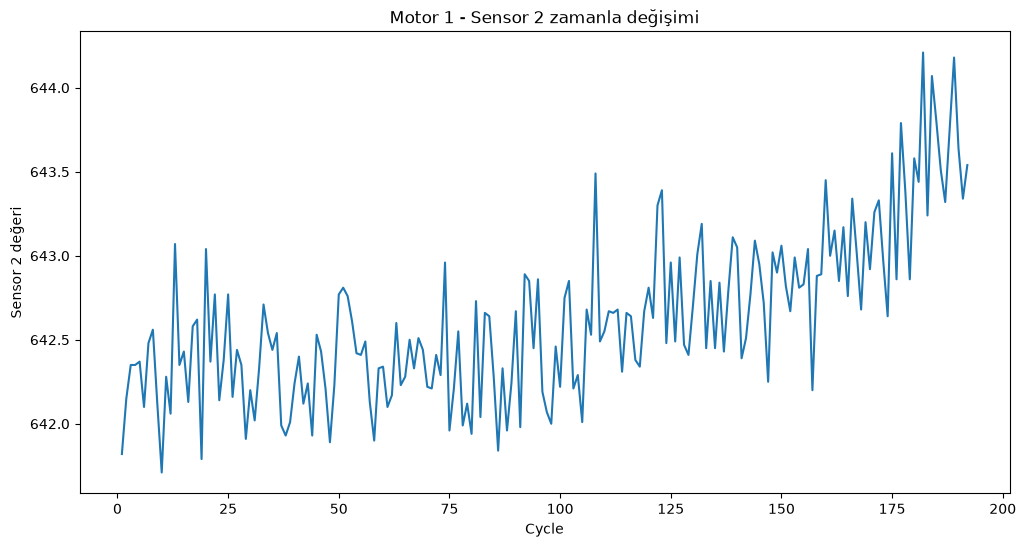

In [97]:
import matplotlib.pyplot as plt

engine_1 = df_train[df_train["unit_number"] == 1]

plt.figure(figsize=(12, 6))
plt.plot(engine_1["time_in_cycles"], engine_1["sensor_2"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2 değeri")
plt.title("Motor 1 - Sensor 2 zamanla değişimi")
plt.show()

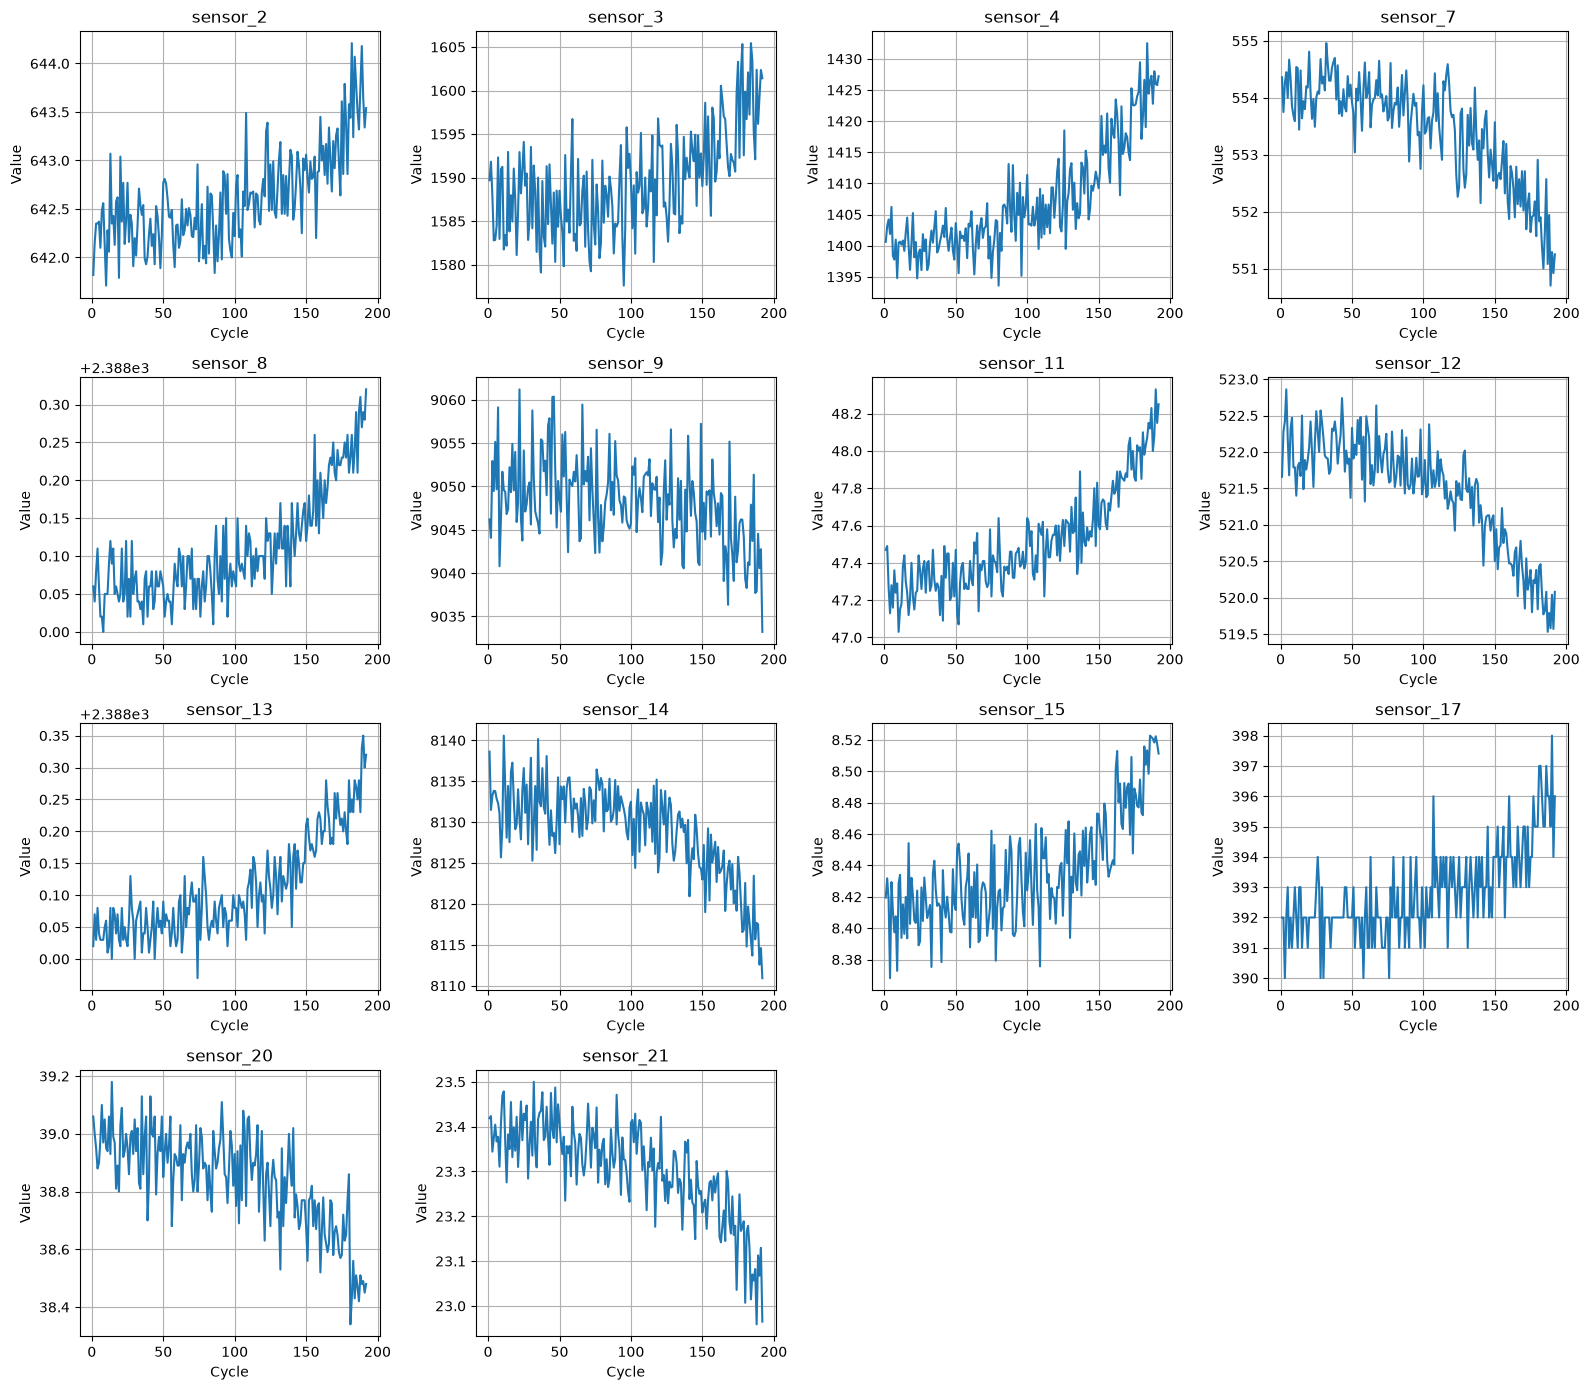

In [98]:
import matplotlib.pyplot as plt

engine_1 = df_train[df_train["unit_number"] == 1]

sensor_columns = [
    col for col in df_train.columns
    if col.startswith("sensor_")
]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):
    axes[i].plot(
        engine_1["time_in_cycles"],
        engine_1[sensor]
    )

    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Value")
    axes[i].grid(True)

for i in range(len(sensor_columns), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

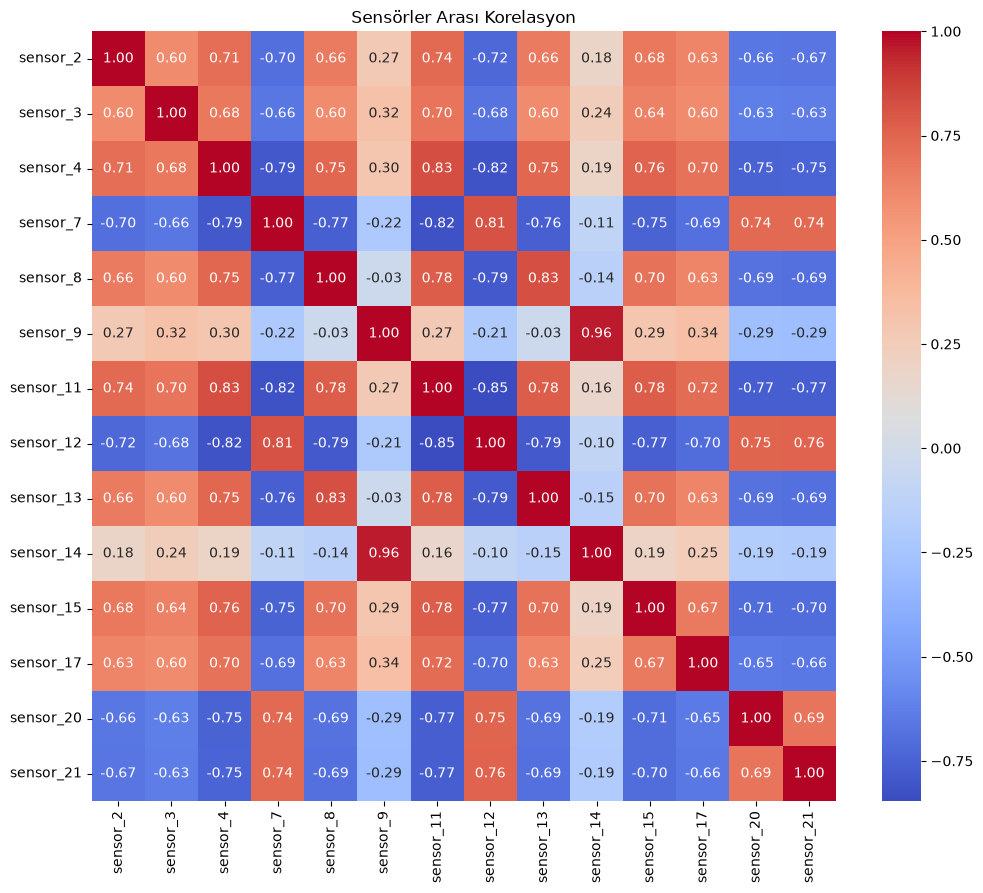

In [99]:
import seaborn as sns

sensor_columns = [
    col for col in df_train.columns
    if col.startswith("sensor_")
]

correlation_matrix = df_train[sensor_columns].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Sensörler Arası Korelasyon")
plt.show()

In [100]:
rul_corr_9 = df_train["sensor_9"].corr(df_train["RUL"])
rul_corr_14 = df_train["sensor_14"].corr(df_train["RUL"])

print("Sensor 9 - RUL korelasyonu:", rul_corr_9)
print("Sensor 14 - RUL korelasyonu:", rul_corr_14)

Sensor 9 - RUL korelasyonu: -0.39010157491807124
Sensor 14 - RUL korelasyonu: -0.30676887025758465


In [101]:
df_train = df_train.drop(columns=["sensor_14"])
df_test = df_test.drop(columns=["sensor_14"])

In [102]:
sensor_columns = [
    col for col in df_train.columns
    if col.startswith("sensor_")
]

rul_correlations = df_train[sensor_columns + ["RUL"]].corr()["RUL"]

rul_correlations = rul_correlations.drop("RUL").sort_values()

print(rul_correlations)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
Name: RUL, dtype: float64


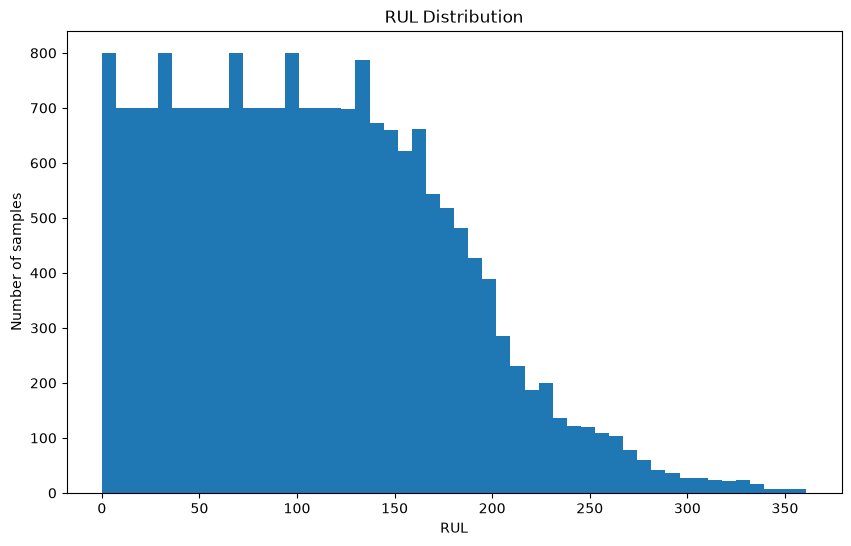

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df_train["RUL"], bins=50)

plt.xlabel("RUL")
plt.ylabel("Number of samples")
plt.title("RUL Distribution")

plt.show()

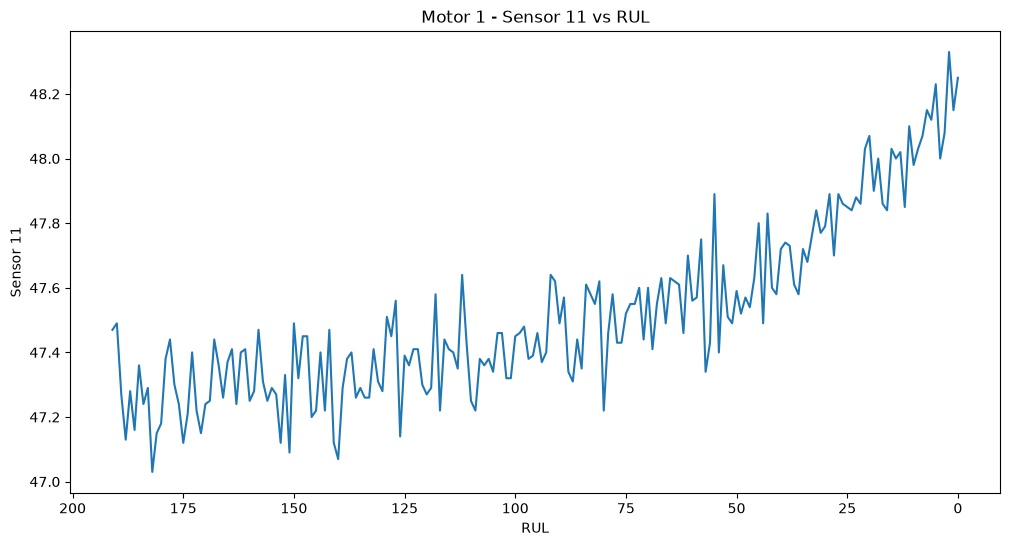

In [104]:
engine_1 = df_train[df_train["unit_number"] == 1]

plt.figure(figsize=(12, 6))

plt.plot(
    engine_1["RUL"],
    engine_1["sensor_11"]
)

plt.xlabel("RUL")
plt.ylabel("Sensor 11")
plt.title("Motor 1 - Sensor 11 vs RUL")

plt.gca().invert_xaxis()

plt.show()

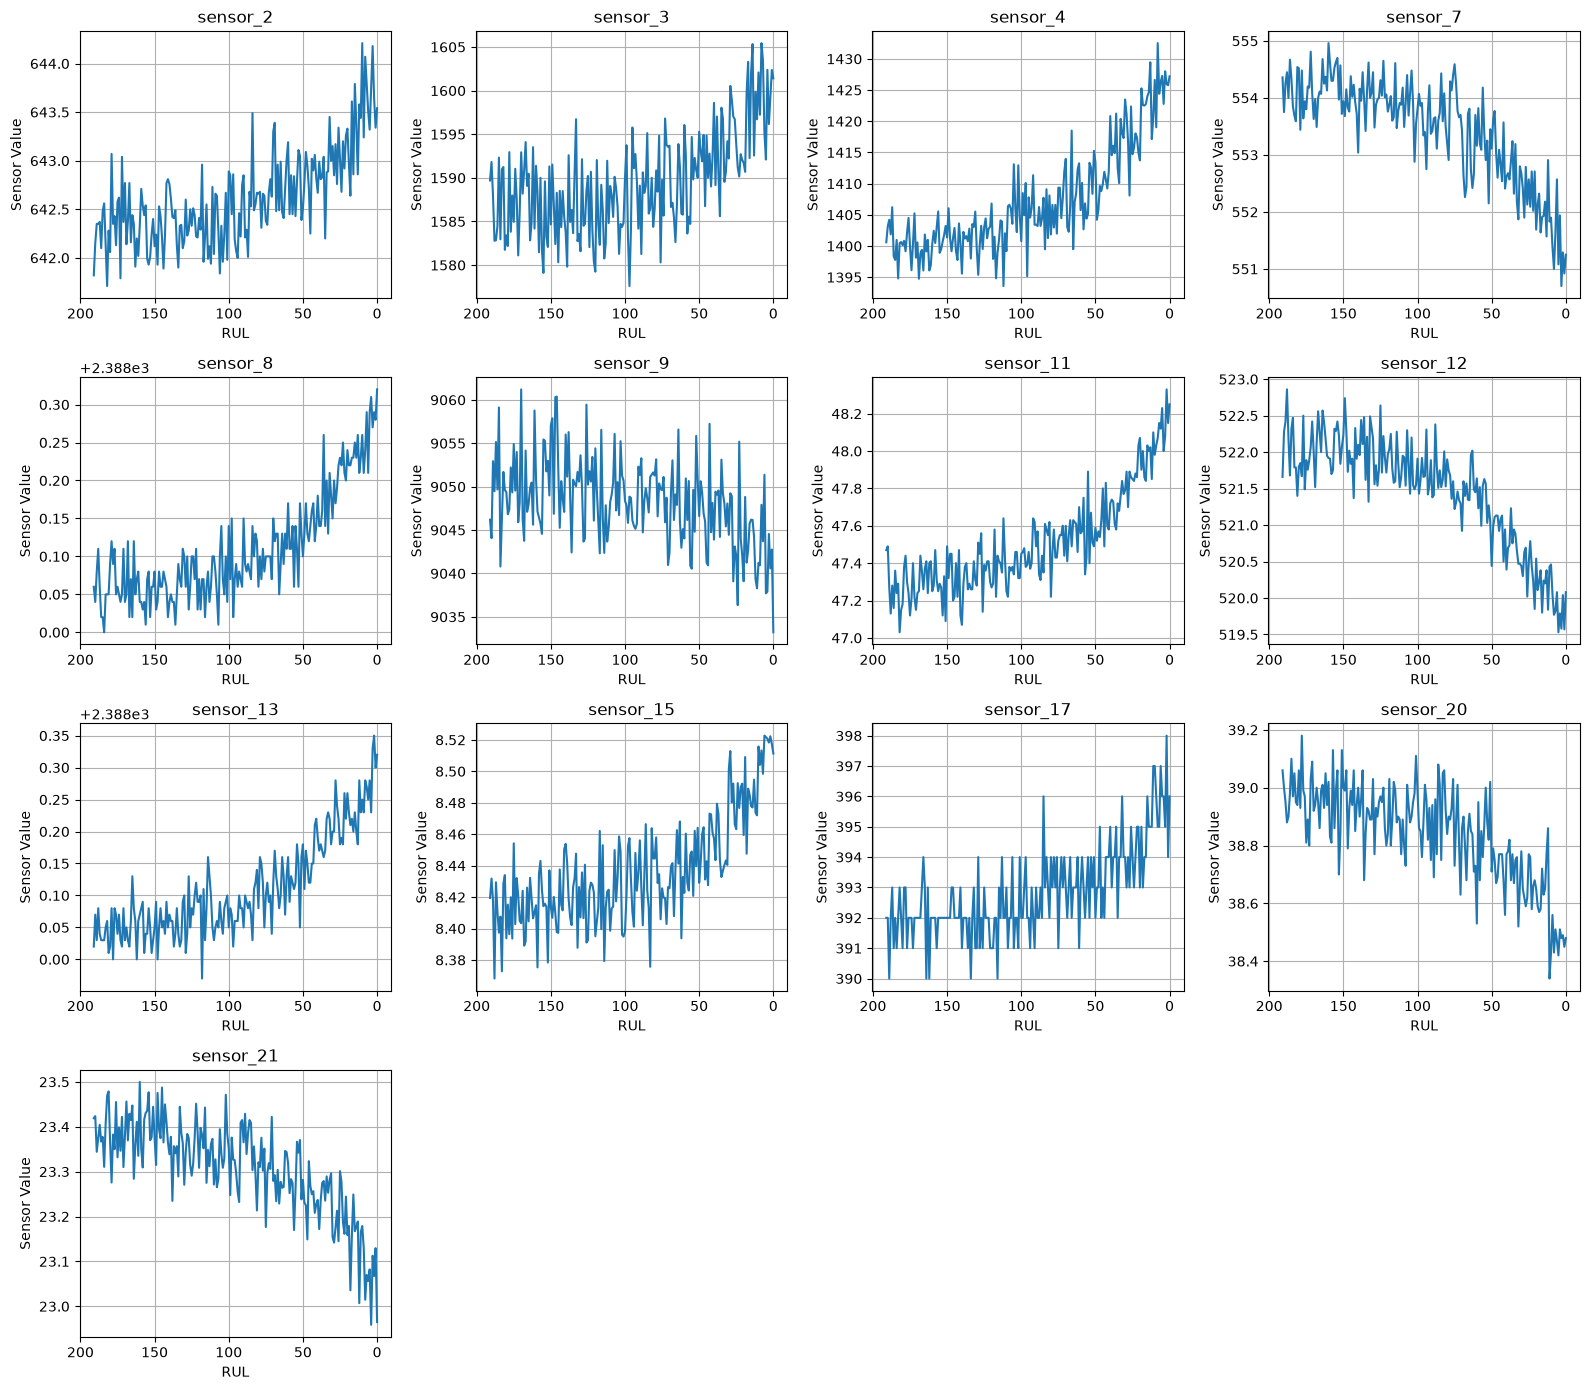

In [105]:
sensor_columns = [
    col for col in df_train.columns
    if col.startswith("sensor_")
]

engine_1 = df_train[df_train["unit_number"] == 1]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):
    axes[i].plot(
        engine_1["RUL"],
        engine_1[sensor]
    )

    axes[i].set_title(sensor)
    axes[i].set_xlabel("RUL")
    axes[i].set_ylabel("Sensor Value")
    axes[i].invert_xaxis()
    axes[i].grid(True)

for i in range(len(sensor_columns), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 6. RUL Hedefinin Sınırlandırılması

Yüksek RUL değerlerinin sensörlerdeki bozulma sinyalini daha az belirgin hale getirmesi nedeniyle hedef değişkeni `125` cycle ile sınırlandırıyoruz.

Böylece modelin özellikle motorların bozulmaya yaklaştığı ve sensörlerde anlamlı değişimlerin başladığı bölgeye odaklanmasını amaçlıyoruz.

Orijinal `RUL` değerini koruyor, modelleme için ayrı bir `RUL_target` değişkeni oluşturuyoruz.


In [106]:
df_train["RUL_target"] = df_train["RUL"].clip(upper=125)

print(df_train[["RUL", "RUL_target"]].head(20))

    RUL  RUL_target
0   191         125
1   190         125
2   189         125
3   188         125
4   187         125
5   186         125
6   185         125
7   184         125
8   183         125
9   182         125
10  181         125
11  180         125
12  179         125
13  178         125
14  177         125
15  176         125
16  175         125
17  174         125
18  173         125
19  172         125


In [107]:
print(df_train[["RUL", "RUL_target"]].tail(20))

       RUL  RUL_target
20611   19          19
20612   18          18
20613   17          17
20614   16          16
20615   15          15
20616   14          14
20617   13          13
20618   12          12
20619   11          11
20620   10          10
20621    9           9
20622    8           8
20623    7           7
20624    6           6
20625    5           5
20626    4           4
20627    3           3
20628    2           2
20629    1           1
20630    0           0


In [108]:
print("Gerçek RUL maksimum:", df_train["RUL"].max())
print("Target RUL maksimum:", df_train["RUL_target"].max())

Gerçek RUL maksimum: 361
Target RUL maksimum: 125


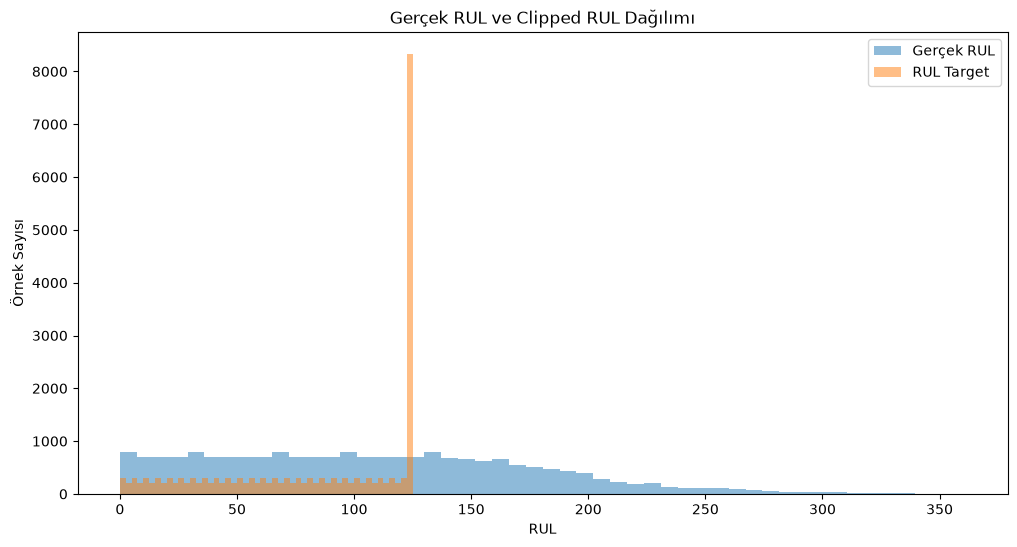

In [109]:
plt.figure(figsize=(12, 6))

plt.hist(df_train["RUL"], bins=50, alpha=0.5, label="Gerçek RUL")
plt.hist(df_train["RUL_target"], bins=50, alpha=0.5, label="RUL Target")

plt.xlabel("RUL")
plt.ylabel("Örnek Sayısı")
plt.title("Gerçek RUL ve Clipped RUL Dağılımı")
plt.legend()
plt.show()

In [110]:
cycle_lengths = (
    df_train.groupby("unit_number")["time_in_cycles"]
    .max()
)

print(cycle_lengths.describe())

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


## 7. Feature Engineering

Sensör verilerindeki gürültüyü azaltmak ve motorun zaman içerisindeki bozulma eğilimini modele daha anlamlı şekilde aktarabilmek için yeni özellikler oluşturuyoruz.

İlk olarak `rolling mean` kullanıyoruz. 10 cycle'lık hareketli ortalama, sensör değerlerini yumuşatarak kısa süreli dalgalanmaların etkisini azaltır ve daha genel bir trendin ortaya çıkmasına yardımcı olur.

Bu projede `window=10` kullanmamızın amacı, sensörlerdeki kısa vadeli gürültüyü azaltırken motorun bozulma sürecindeki değişimleri korumaktır.

Önce Motor 1 üzerinde örnek olarak `sensor_11` için rolling mean oluşturuyor, ardından aynı yaklaşımı gerekli sensörlere uyguluyoruz.


In [111]:
engine_1 = df_train[df_train["unit_number"] == 1].copy()

engine_1["sensor_11_rolling_mean_10"] = (
    engine_1["sensor_11"]
    .rolling(window=10, min_periods=1)
    .mean()
)

print(
    engine_1[
        [
            "time_in_cycles",
            "sensor_11",
            "sensor_11_rolling_mean_10"
        ]
    ].head(15)
)

    time_in_cycles  sensor_11  sensor_11_rolling_mean_10
0                1      47.47                  47.470000
1                2      47.49                  47.480000
2                3      47.27                  47.410000
3                4      47.13                  47.340000
4                5      47.28                  47.328000
5                6      47.16                  47.300000
6                7      47.36                  47.308571
7                8      47.24                  47.300000
8                9      47.29                  47.298889
9               10      47.03                  47.272000
10              11      47.15                  47.240000
11              12      47.18                  47.209000
12              13      47.38                  47.220000
13              14      47.44                  47.251000
14              15      47.30                  47.253000


In [112]:
engine_1["sensor_11_trend_10"] = (
    engine_1["sensor_11_rolling_mean_10"]
    .rolling(window=10, min_periods=2)
    .apply(
        lambda x: np.polyfit(np.arange(len(x)), x, 1)[0],
        raw=True
    )
)

print(
    engine_1[
        [
            "time_in_cycles",
            "sensor_11",
            "sensor_11_rolling_mean_10",
            "sensor_11_trend_10"
        ]
    ].head(20)
)

    time_in_cycles  sensor_11  sensor_11_rolling_mean_10  sensor_11_trend_10
0                1      47.47                  47.470000                 NaN
1                2      47.49                  47.480000            0.010000
2                3      47.27                  47.410000           -0.030000
3                4      47.13                  47.340000           -0.046000
4                5      47.28                  47.328000           -0.042400
5                6      47.16                  47.300000           -0.039314
6                7      47.36                  47.308571           -0.033082
7                8      47.24                  47.300000           -0.028442
8                9      47.29                  47.298889           -0.024455
9               10      47.03                  47.272000           -0.022558
10              11      47.15                  47.240000           -0.020648
11              12      47.18                  47.209000           -0.016975

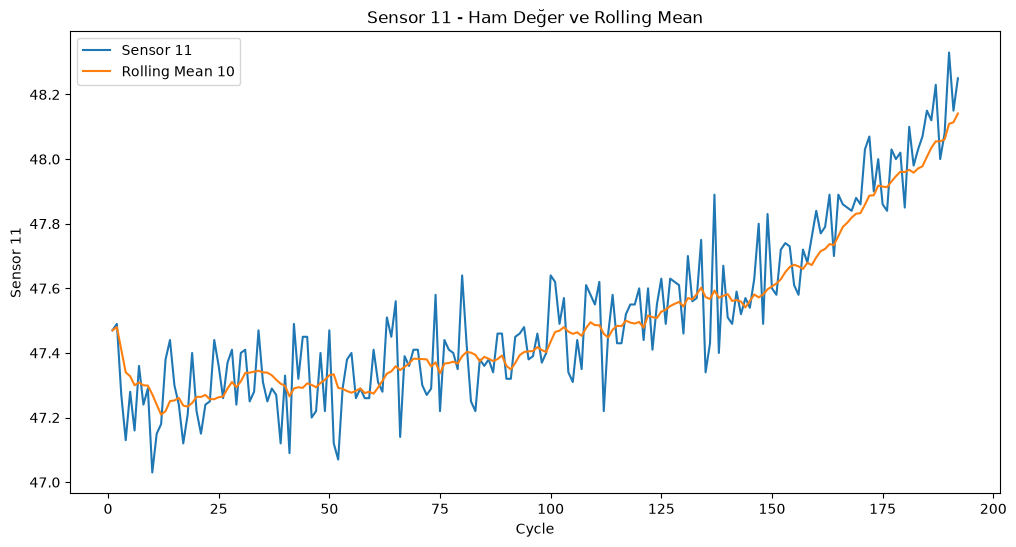

In [113]:
plt.figure(figsize=(12, 6))

plt.plot(
    engine_1["time_in_cycles"],
    engine_1["sensor_11"],
    label="Sensor 11"
)

plt.plot(
    engine_1["time_in_cycles"],
    engine_1["sensor_11_rolling_mean_10"],
    label="Rolling Mean 10"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 - Ham Değer ve Rolling Mean")
plt.legend()
plt.show()

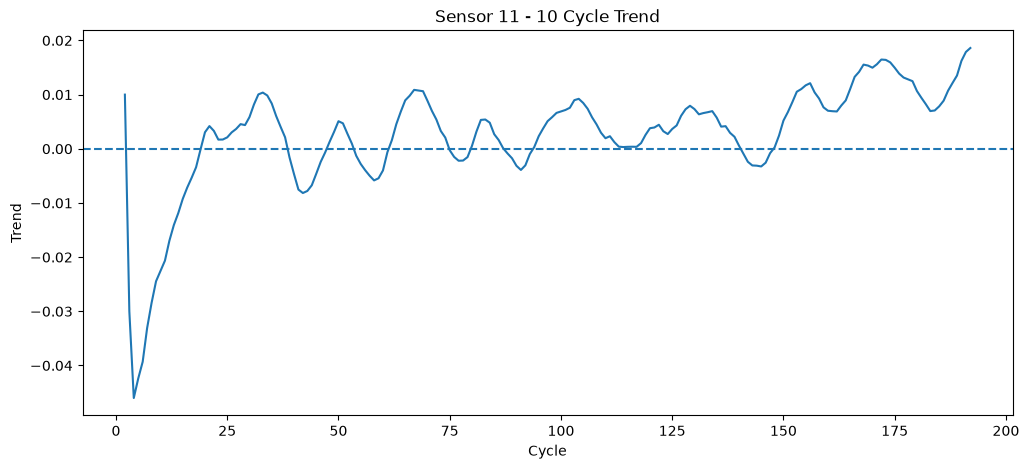

In [114]:
plt.figure(figsize=(12, 5))

plt.plot(
    engine_1["time_in_cycles"],
    engine_1["sensor_11_trend_10"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Cycle")
plt.ylabel("Trend")
plt.title("Sensor 11 - 10 Cycle Trend")
plt.show()

In [115]:
trend_rul_corr = engine_1[
    ["sensor_11_trend_10", "RUL"]
].corr()

print(trend_rul_corr)

                    sensor_11_trend_10       RUL
sensor_11_trend_10            1.000000 -0.617972
RUL                          -0.617972  1.000000


In [116]:
correlation_comparison = engine_1[
    [
        "sensor_11",
        "sensor_11_rolling_mean_10",
        "sensor_11_trend_10",
        "RUL"
    ]
].corr()["RUL"]

print(correlation_comparison)

sensor_11                   -0.842075
sensor_11_rolling_mean_10   -0.900684
sensor_11_trend_10          -0.617972
RUL                          1.000000
Name: RUL, dtype: float64


In [117]:
sensor_columns = [
    col for col in df_train.columns
    if col.startswith("sensor_")
]

print(sensor_columns)
print("Sensör sayısı:", len(sensor_columns))

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Sensör sayısı: 13


In [118]:
def add_rolling_std(df, sensors, window=10):
    df = df.copy()

    for sensor in sensors:
        df[f"{sensor}_rolling_std_10"] = (
            df.groupby("unit_number")[sensor]
            .rolling(window=window, min_periods=1)
            .std()
            .reset_index(level=0, drop=True)
        )

    return df

In [119]:
df_train_features = add_rolling_std(
    df_train,
    sensor_columns
)

print(df_train_features.head())

   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1       -0.0007       -0.0004         100.0   
1            1               2        0.0019       -0.0003         100.0   
2            1               3       -0.0043        0.0003         100.0   
3            1               4        0.0007        0.0000         100.0   
4            1               5       -0.0019       -0.0002         100.0   

   sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  ...  \
0    641.82   1589.70   1400.60    554.36   2388.06  ...   
1    642.15   1591.82   1403.14    553.75   2388.04  ...   
2    642.35   1587.99   1404.20    554.26   2388.08  ...   
3    642.35   1582.79   1401.87    554.45   2388.11  ...   
4    642.37   1582.85   1406.22    554.00   2388.06  ...   

   sensor_7_rolling_std_10  sensor_8_rolling_std_10  sensor_9_rolling_std_10  \
0                      NaN                      NaN                      NaN   
1                 0.43

In [120]:
rolling_std_columns = [
    col for col in df_train_features.columns
    if col.endswith("_rolling_std_10")
]

print(rolling_std_columns)
print("Toplam rolling std feature sayısı:", len(rolling_std_columns))

['sensor_2_rolling_std_10', 'sensor_3_rolling_std_10', 'sensor_4_rolling_std_10', 'sensor_7_rolling_std_10', 'sensor_8_rolling_std_10', 'sensor_9_rolling_std_10', 'sensor_11_rolling_std_10', 'sensor_12_rolling_std_10', 'sensor_13_rolling_std_10', 'sensor_15_rolling_std_10', 'sensor_17_rolling_std_10', 'sensor_20_rolling_std_10', 'sensor_21_rolling_std_10']
Toplam rolling std feature sayısı: 13


In [121]:
rolling_std_rul_corr = (
    df_train_features[rolling_std_columns + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values()
)

print(rolling_std_rul_corr)

sensor_9_rolling_std_10    -0.227026
sensor_11_rolling_std_10   -0.092424
sensor_12_rolling_std_10   -0.079751
sensor_13_rolling_std_10   -0.079290
sensor_4_rolling_std_10    -0.071453
sensor_20_rolling_std_10   -0.066284
sensor_17_rolling_std_10   -0.055500
sensor_8_rolling_std_10    -0.046838
sensor_7_rolling_std_10    -0.043933
sensor_15_rolling_std_10   -0.042106
sensor_2_rolling_std_10    -0.028793
sensor_3_rolling_std_10    -0.010967
sensor_21_rolling_std_10   -0.001129
Name: RUL, dtype: float64


In [122]:
feature_columns = [
    col for col in df_train_features.columns
    if col.startswith("sensor_")
]

print("Feature sayısı:", len(feature_columns))

feature_corr = df_train_features[feature_columns].corr()

print(feature_corr.shape)

Feature sayısı: 26
(26, 26)


In [123]:
corr_pairs = (
    feature_corr
    .where(~np.eye(feature_corr.shape[0], dtype=bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(20))

sensor_11  sensor_12   -0.846884
sensor_12  sensor_11   -0.846884
sensor_4   sensor_11    0.830136
sensor_11  sensor_4     0.830136
sensor_8   sensor_13    0.826084
sensor_13  sensor_8     0.826084
sensor_7   sensor_11   -0.822805
sensor_11  sensor_7    -0.822805
sensor_12  sensor_4    -0.815591
sensor_4   sensor_12   -0.815591
sensor_12  sensor_7     0.812713
sensor_7   sensor_12    0.812713
           sensor_4    -0.793130
sensor_4   sensor_7    -0.793130
sensor_13  sensor_12   -0.788441
sensor_12  sensor_13   -0.788441
sensor_8   sensor_12   -0.786540
sensor_12  sensor_8    -0.786540
sensor_11  sensor_8     0.782213
sensor_8   sensor_11    0.782213
dtype: float64


In [124]:
sensor_columns = [
    col for col in df_train_features.columns
    if col.startswith("sensor_") and "rolling" not in col and "trend" not in col
]

sensor_rul_corr = (
    df_train_features[sensor_columns + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values(key=abs, ascending=False)
)

print(sensor_rul_corr)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15   -0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
Name: RUL, dtype: float64


In [125]:
def add_rolling_mean(df, sensors, window=10):
    df = df.copy()

    for sensor in sensors:
        df[f"{sensor}_rolling_mean_10"] = (
            df.groupby("unit_number")[sensor]
            .rolling(window=window, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

    return df

In [126]:
df_train_features = add_rolling_mean(
    df_train_features,
    sensor_columns,
    window=10
)

In [127]:
df_train_features[
    [
        "unit_number",
        "time_in_cycles",
        "sensor_11",
        "sensor_11_rolling_mean_10"
    ]
].head(15)

,unit_number,time_in_cycles,sensor_11,sensor_11_rolling_mean_10
0,1,1,47.47,47.470000
1,1,2,47.49,47.480000
2,1,3,47.27,47.410000
3,1,4,47.13,47.340000
4,1,5,47.28,47.328000
5,1,6,47.16,47.300000
6,1,7,47.36,47.308571
7,1,8,47.24,47.300000
8,1,9,47.29,47.298889
9,1,10,47.03,47.272000


In [128]:
df_train_features[
    [
        "unit_number",
        "time_in_cycles",
        "sensor_11",
        "sensor_11_rolling_mean_10"
    ]
].query("unit_number == 2").head(10)

,unit_number,time_in_cycles,sensor_11,sensor_11_rolling_mean_10
192,2,1,46.93,46.930000
193,2,2,47.24,47.085000
194,2,3,47.22,47.130000
195,2,4,47.10,47.122500
196,2,5,47.25,47.148000
197,2,6,47.05,47.131667
198,2,7,47.10,47.127143
199,2,8,47.20,47.136250
200,2,9,47.14,47.136667
201,2,10,47.21,47.144000


In [129]:
def add_rolling_trend(df, sensors, window=10):
    df = df.copy()

    for sensor in sensors:
        df[f"{sensor}_trend_10"] = (
            df.groupby("unit_number")[sensor]
            .transform(
                lambda x: x.rolling(window=window, min_periods=2)
                .apply(
                    lambda y: np.polyfit(np.arange(len(y)), y, 1)[0],
                    raw=True
                )
            )
        )

    return df

In [130]:
df_train_features = add_rolling_trend(
    df_train_features,
    sensor_columns,
    window=10
)

In [131]:
df_train_features[
    [
        "unit_number",
        "time_in_cycles",
        "sensor_11",
        "sensor_11_trend_10"
    ]
].head(20)

,unit_number,time_in_cycles,sensor_11,sensor_11_trend_10
0,1,1,47.47,NaN
1,1,2,47.49,0.020000
2,1,3,47.27,-0.100000
3,1,4,47.13,-0.124000
4,1,5,47.28,-0.074000
5,1,6,47.16,-0.066286
6,1,7,47.36,-0.035000
7,1,8,47.24,-0.029048
8,1,9,47.29,-0.021000
9,1,10,47.03,-0.029939


In [132]:
from sklearn.model_selection import GroupKFold

## 8. Modelleme ve Validation

Model performansını değerlendirirken aynı motorun hem eğitim hem validation verisinde bulunmasını engellemek için `GroupKFold` kullanıyoruz.

`unit_number` grup değişkeni olarak kullanılarak her fold'da farklı motorlar validation için ayrılıyor.

İlk olarak **Random Forest** ile baseline bir model oluşturuyor, ardından MAE ve RMSE metrikleri üzerinden performansı değerlendiriyoruz.


In [133]:
gkf = GroupKFold(n_splits=5)

In [134]:
X = df_train_features[feature_columns]
y = df_train_features["RUL"]
groups = df_train_features["unit_number"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    train_units = df_train_features.iloc[train_idx]["unit_number"].unique()
    val_units = df_train_features.iloc[val_idx]["unit_number"].unique()

    print(f"Fold {fold}")
    print("Train motor sayısı:", len(train_units))
    print("Validation motor sayısı:", len(val_units))
    print("Ortak motor:", set(train_units) & set(val_units))
    print()

Fold 1
Train motor sayısı: 80
Validation motor sayısı: 20
Ortak motor: set()

Fold 2
Train motor sayısı: 80
Validation motor sayısı: 20
Ortak motor: set()

Fold 3
Train motor sayısı: 80
Validation motor sayısı: 20
Ortak motor: set()

Fold 4
Train motor sayısı: 80
Validation motor sayısı: 20
Ortak motor: set()

Fold 5
Train motor sayısı: 80
Validation motor sayısı: 20
Ortak motor: set()



In [135]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [136]:
gkf = GroupKFold(n_splits=5)

X = df_train_features[feature_columns]
y = df_train_features["RUL"]
groups = df_train_features["unit_number"]

mae_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"Fold {fold}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print()

Fold 1
MAE: 31.718
RMSE: 45.969

Fold 2
MAE: 29.311
RMSE: 42.648

Fold 3
MAE: 31.794
RMSE: 43.618

Fold 4
MAE: 29.688
RMSE: 41.587

Fold 5
MAE: 29.913
RMSE: 40.669



In [137]:
train_mae_scores = []
train_rmse_scores = []

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)

    print(f"Fold {fold}")
    print(f"Train MAE: {train_mae:.3f}")
    print(f"Validation MAE: {val_mae:.3f}")
    print(f"Train RMSE: {train_rmse:.3f}")
    print(f"Validation RMSE: {val_rmse:.3f}")
    print()

Fold 1
Train MAE: 10.065
Validation MAE: 31.718
Train RMSE: 14.254
Validation RMSE: 45.969

Fold 2
Train MAE: 10.229
Validation MAE: 29.311
Train RMSE: 14.489
Validation RMSE: 42.648

Fold 3
Train MAE: 10.217
Validation MAE: 31.794
Train RMSE: 14.525
Validation RMSE: 43.618

Fold 4
Train MAE: 10.332
Validation MAE: 29.688
Train RMSE: 14.658
Validation RMSE: 41.587

Fold 5
Train MAE: 10.401
Validation MAE: 29.913
Train RMSE: 14.771
Validation RMSE: 40.669



In [138]:
results = []

parameters = [
    {"max_depth": 5, "min_samples_leaf": 1},
    {"max_depth": 10, "min_samples_leaf": 1},
    {"max_depth": 15, "min_samples_leaf": 1},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 5},
]

for params in parameters:

    mae_scores = []
    rmse_scores = []
    train_mae_scores = []

    for train_idx, val_idx in gkf.split(X, y, groups=groups):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_mae_scores.append(
            mean_absolute_error(y_train, train_pred)
        )

        mae_scores.append(
            mean_absolute_error(y_val, val_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, val_pred))
        )

    results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "train_mae": np.mean(train_mae_scores),
        "val_mae": np.mean(mae_scores),
        "val_rmse": np.mean(rmse_scores)
    })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  min_samples_leaf  train_mae    val_mae   val_rmse
0          5                 1  30.490161  31.832892  44.175457
1         10                 1  24.330133  30.361500  42.743444
2         15                 1  16.343721  30.363829  42.753228
3         10                 5  24.471334  30.353288  42.744433
4         15                 5  18.306168  30.366704  42.784417


In [139]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [140]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print(feature_importance)

sensor_11                   0.580481
sensor_9                    0.147675
sensor_4                    0.098154
sensor_12                   0.031283
sensor_7                    0.018692
sensor_15                   0.011165
sensor_21                   0.009357
sensor_15_rolling_std_10    0.008363
sensor_3_rolling_std_10     0.007155
sensor_20_rolling_std_10    0.007152
sensor_13                   0.006650
sensor_11_rolling_std_10    0.006536
sensor_12_rolling_std_10    0.006502
sensor_2                    0.006203
sensor_20                   0.005998
sensor_4_rolling_std_10     0.005376
sensor_8                    0.005309
sensor_3                    0.005234
sensor_13_rolling_std_10    0.004962
sensor_8_rolling_std_10     0.004686
sensor_21_rolling_std_10    0.004650
sensor_7_rolling_std_10     0.004413
sensor_17_rolling_std_10    0.004258
sensor_9_rolling_std_10     0.004108
sensor_2_rolling_std_10     0.003978
sensor_17                   0.001659
dtype: float64


In [141]:
print([
    col for col in df_train_features.columns
    if "rolling_mean" in col or "trend" in col
])

['sensor_2_rolling_mean_10', 'sensor_3_rolling_mean_10', 'sensor_4_rolling_mean_10', 'sensor_7_rolling_mean_10', 'sensor_8_rolling_mean_10', 'sensor_9_rolling_mean_10', 'sensor_11_rolling_mean_10', 'sensor_12_rolling_mean_10', 'sensor_13_rolling_mean_10', 'sensor_15_rolling_mean_10', 'sensor_17_rolling_mean_10', 'sensor_20_rolling_mean_10', 'sensor_21_rolling_mean_10', 'sensor_2_trend_10', 'sensor_3_trend_10', 'sensor_4_trend_10', 'sensor_7_trend_10', 'sensor_8_trend_10', 'sensor_9_trend_10', 'sensor_11_trend_10', 'sensor_12_trend_10', 'sensor_13_trend_10', 'sensor_15_trend_10', 'sensor_17_trend_10', 'sensor_20_trend_10', 'sensor_21_trend_10']


In [142]:
print("Feature columns sayısı:", len(feature_columns))

print("\nFeature columns:")
print(feature_columns)

Feature columns sayısı: 26

Feature columns:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_rolling_std_10', 'sensor_3_rolling_std_10', 'sensor_4_rolling_std_10', 'sensor_7_rolling_std_10', 'sensor_8_rolling_std_10', 'sensor_9_rolling_std_10', 'sensor_11_rolling_std_10', 'sensor_12_rolling_std_10', 'sensor_13_rolling_std_10', 'sensor_15_rolling_std_10', 'sensor_17_rolling_std_10', 'sensor_20_rolling_std_10', 'sensor_21_rolling_std_10']


In [143]:
print("\nDataFrame kolon sayısı:", len(df_train_features.columns))


DataFrame kolon sayısı: 60


In [144]:
feature_columns = [
    col for col in df_train_features.columns
    if col.startswith("sensor_")
]

In [145]:
print("Feature sayısı:", len(feature_columns))
print(feature_columns)

Feature sayısı: 52
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_rolling_std_10', 'sensor_3_rolling_std_10', 'sensor_4_rolling_std_10', 'sensor_7_rolling_std_10', 'sensor_8_rolling_std_10', 'sensor_9_rolling_std_10', 'sensor_11_rolling_std_10', 'sensor_12_rolling_std_10', 'sensor_13_rolling_std_10', 'sensor_15_rolling_std_10', 'sensor_17_rolling_std_10', 'sensor_20_rolling_std_10', 'sensor_21_rolling_std_10', 'sensor_2_rolling_mean_10', 'sensor_3_rolling_mean_10', 'sensor_4_rolling_mean_10', 'sensor_7_rolling_mean_10', 'sensor_8_rolling_mean_10', 'sensor_9_rolling_mean_10', 'sensor_11_rolling_mean_10', 'sensor_12_rolling_mean_10', 'sensor_13_rolling_mean_10', 'sensor_15_rolling_mean_10', 'sensor_17_rolling_mean_10', 'sensor_20_rolling_mean_10', 'sensor_21_rolling_mean_10', 'sensor_2_trend_10', 'sensor_3_trend_10', 'sensor_4_trend_10', 'sensor_7_trend_10', 'sen

In [146]:
X = df_train_features[feature_columns]
y = df_train_features["RUL"]
groups = df_train_features["unit_number"]

print("X shape:", X.shape)

X shape: (20631, 52)


## 9. Feature Importance Analizi

Eğitilen Random Forest modelinin hangi feature'lara daha fazla önem verdiğini incelemek için feature importance değerlerini hesaplıyoruz.

Bu analiz, oluşturduğumuz ham sensör, rolling mean, rolling std ve trend feature'larından hangilerinin modelin tahminlerinde daha etkili olduğunu anlamamıza yardımcı olur.

Feature importance değerleri tek başına nedensellik göstermez; yalnızca modelin kararlarında feature'ların göreceli katkısını gösterir.


In [147]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print(feature_importance)

sensor_4_rolling_mean_10     0.582403
sensor_9_rolling_mean_10     0.116769
sensor_21_rolling_mean_10    0.093832
sensor_11_rolling_mean_10    0.029577
sensor_3_rolling_mean_10     0.013632
sensor_7_rolling_mean_10     0.013431
sensor_13_rolling_mean_10    0.013010
sensor_2_rolling_mean_10     0.012926
sensor_15_rolling_mean_10    0.011324
sensor_8_rolling_mean_10     0.010430
sensor_12_rolling_mean_10    0.007969
sensor_20_rolling_mean_10    0.006905
sensor_9                     0.006469
sensor_12_rolling_std_10     0.005109
sensor_9_rolling_std_10      0.005018
sensor_15_rolling_std_10     0.004393
sensor_7_rolling_std_10      0.004306
sensor_11_rolling_std_10     0.004098
sensor_20_rolling_std_10     0.003950
sensor_3_rolling_std_10      0.003688
sensor_17_rolling_mean_10    0.003644
sensor_2_rolling_std_10      0.003615
sensor_13_trend_10           0.003527
sensor_8_rolling_std_10      0.003485
sensor_21_rolling_std_10     0.003307
sensor_13_rolling_std_10     0.003091
sensor_8_tre

In [148]:
mae_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"Fold {fold}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print()

print("Ortalama MAE:", np.mean(mae_scores))
print("Ortalama RMSE:", np.mean(rmse_scores))

Fold 1
MAE: 31.465
RMSE: 46.652

Fold 2
MAE: 28.755
RMSE: 41.827

Fold 3
MAE: 30.893
RMSE: 42.430

Fold 4
MAE: 29.763
RMSE: 41.995

Fold 5
MAE: 29.641
RMSE: 41.690

Ortalama MAE: 30.10342528740578
Ortalama RMSE: 42.91892173470574


## 10. Feature Selection

Random Forest modelinden elde edilen feature importance değerlerini kullanarak farklı sayıda feature ile model performansını karşılaştırıyoruz.

En önemli 10, 20, 30, 40 ve 52 feature seçilerek her feature seti `GroupKFold` ile değerlendirilir. Amaç, daha az feature kullanarak benzer veya daha iyi performans elde edip edemediğimizi görmek ve gereksiz feature'ları azaltmaktır.

Performans karşılaştırması MAE ve RMSE metrikleri üzerinden yapılır.


In [149]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

feature_counts = [10, 20, 30, 40, 52]

selection_results = []

for n_features in feature_counts:

    selected_features = feature_importance.head(n_features).index

    X_selected = df_train_features[selected_features]

    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_selected,
        y,
        groups=groups
    ):

        X_train = X_selected.iloc[train_idx]
        X_val = X_selected.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    selection_results.append({
        "feature_count": n_features,
        "mean_mae": np.mean(mae_scores),
        "mean_rmse": np.mean(rmse_scores)
    })

selection_results_df = pd.DataFrame(selection_results)

print(selection_results_df)

   feature_count   mean_mae  mean_rmse
0             10  31.043583  44.267468
1             20  30.614654  43.510672
2             30  30.289630  43.121683
3             40  30.113472  42.932099
4             52  30.104804  42.921567


## 11. XGBoost Modeli

Random Forest sonuçlarını karşılaştırmak için XGBoost tabanlı bir regresyon modeli kullanıyoruz.

XGBoost, ağaç tabanlı modelleri ardışık olarak oluşturarak önceki modellerin hatalarını azaltmaya çalışır. Bu nedenle karmaşık ve doğrusal olmayan sensör ilişkilerini modellemek için uygun bir yöntemdir.


In [150]:
import xgboost as xgb

In [151]:
print(xgb.__version__)

3.4.1


In [152]:
mae_scores = []
rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"Fold {fold} MAE: {mae:.3f} RMSE: {rmse:.3f}")

print()
print("Ortalama MAE:", np.mean(mae_scores))
print("Ortalama RMSE:", np.mean(rmse_scores))

Fold 1 MAE: 30.760 RMSE: 45.640
Fold 2 MAE: 28.307 RMSE: 41.107
Fold 3 MAE: 30.315 RMSE: 41.970
Fold 4 MAE: 30.234 RMSE: 42.549
Fold 5 MAE: 29.770 RMSE: 41.122

Ortalama MAE: 29.87714500427246
Ortalama RMSE: 42.47763776939457


In [153]:
top_30_features = feature_importance.head(30).index.tolist()

X_top30 = X[top_30_features]

print("Seçilen feature sayısı:", len(top_30_features))
print(top_30_features)

Seçilen feature sayısı: 30
['sensor_4_rolling_mean_10', 'sensor_9_rolling_mean_10', 'sensor_21_rolling_mean_10', 'sensor_11_rolling_mean_10', 'sensor_13_rolling_mean_10', 'sensor_3_rolling_mean_10', 'sensor_7_rolling_mean_10', 'sensor_2_rolling_mean_10', 'sensor_15_rolling_mean_10', 'sensor_8_rolling_mean_10', 'sensor_12_rolling_mean_10', 'sensor_15_rolling_std_10', 'sensor_20_rolling_mean_10', 'sensor_3_rolling_std_10', 'sensor_4_rolling_std_10', 'sensor_13_rolling_std_10', 'sensor_17_rolling_mean_10', 'sensor_12_rolling_std_10', 'sensor_7_rolling_std_10', 'sensor_8_rolling_std_10', 'sensor_2_rolling_std_10', 'sensor_11_rolling_std_10', 'sensor_9_rolling_std_10', 'sensor_21_rolling_std_10', 'sensor_9', 'sensor_20_rolling_std_10', 'sensor_17_rolling_std_10', 'sensor_11_trend_10', 'sensor_8_trend_10', 'sensor_3_trend_10']


In [154]:
mae_scores_30 = []
rmse_scores_30 = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_top30, y, groups=groups),
    start=1
):

    X_train = X_top30.iloc[train_idx]
    X_val = X_top30.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model_30 = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_model_30.fit(X_train, y_train)

    y_pred = xgb_model_30.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mae_scores_30.append(mae)
    rmse_scores_30.append(rmse)

    print(f"Fold {fold} MAE: {mae:.3f} RMSE: {rmse:.3f}")

print()
print("30 Feature Ortalama MAE:", np.mean(mae_scores_30))
print("30 Feature Ortalama RMSE:", np.mean(rmse_scores_30))

Fold 1 MAE: 31.347 RMSE: 46.452
Fold 2 MAE: 28.999 RMSE: 42.065
Fold 3 MAE: 31.189 RMSE: 43.044
Fold 4 MAE: 30.531 RMSE: 43.013
Fold 5 MAE: 30.298 RMSE: 41.869

30 Feature Ortalama MAE: 30.472835540771484
30 Feature Ortalama RMSE: 43.2886122861111


In [155]:
results = pd.DataFrame({
    "actual_rul": y_val.values,
    "predicted_rul": y_pred
})

results["error"] = results["predicted_rul"] - results["actual_rul"]
results["absolute_error"] = results["error"].abs()

results.head(10)

,actual_rul,predicted_rul,error,absolute_error
0,286,240.030685,-45.969315,45.969315
1,285,223.825165,-61.174835,61.174835
2,284,209.138077,-74.861923,74.861923
3,283,200.992142,-82.007858,82.007858
4,282,193.698700,-88.301300,88.301300
5,281,196.533127,-84.466873,84.466873
6,280,199.605835,-80.394165,80.394165
7,279,195.004639,-83.995361,83.995361
8,278,201.564575,-76.435425,76.435425
9,277,209.252457,-67.747543,67.747543


In [156]:
print("Mean Absolute Error:", results["absolute_error"].mean())
print("Maximum Absolute Error:", results["absolute_error"].max())
print("Mean Error:", results["error"].mean())

Mean Absolute Error: 30.297665107447354
Maximum Absolute Error: 195.19216918945312
Mean Error: 5.316582404447145


In [157]:
results = pd.DataFrame({
    "unit_number": df_train_features.iloc[val_idx]["unit_number"].values,
    "actual_rul": y_val.values,
    "predicted_rul": y_pred
})

results["error"] = results["predicted_rul"] - results["actual_rul"]
results["absolute_error"] = results["error"].abs()

results.sort_values("absolute_error", ascending=False).head(10)

,unit_number,actual_rul,predicted_rul,error,absolute_error
3851,90,73,268.192169,195.192169,195.192169
3849,90,75,262.486176,187.486176,187.486176
3848,90,76,263.463837,187.463837,187.463837
3850,90,74,239.145523,165.145523,165.145523
2073,56,265,109.686180,-155.313820,155.313820
2074,56,264,109.700371,-154.299629,154.299629
2069,56,269,116.237785,-152.762215,152.762215
2081,56,257,105.199242,-151.800758,151.800758
2072,56,266,115.707390,-150.292610,150.292610
2068,56,270,120.947578,-149.052422,149.052422


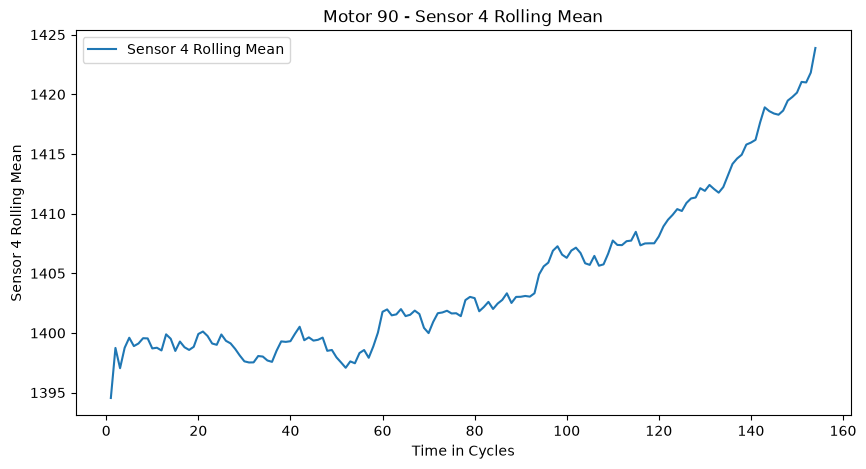

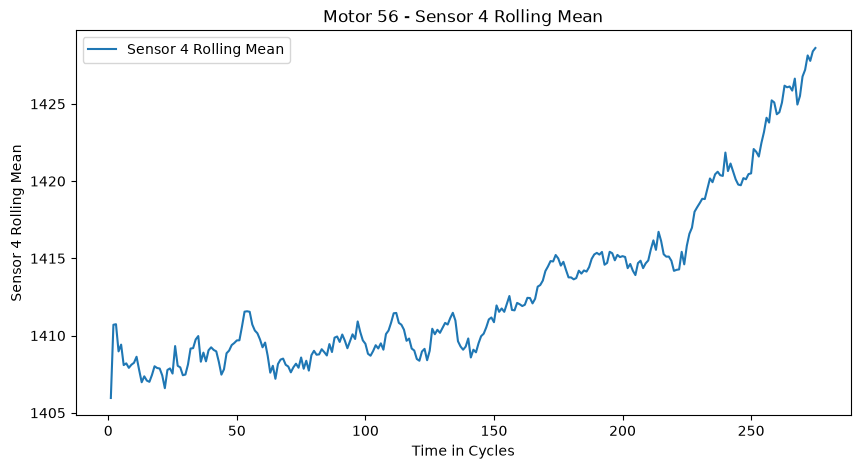

In [158]:
import matplotlib.pyplot as plt

for unit in [90, 56]:
    unit_data = df_train_features[
        df_train_features["unit_number"] == unit
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        unit_data["time_in_cycles"],
        unit_data["sensor_4_rolling_mean_10"],
        label="Sensor 4 Rolling Mean"
    )

    plt.xlabel("Time in Cycles")
    plt.ylabel("Sensor 4 Rolling Mean")
    plt.title(f"Motor {unit} - Sensor 4 Rolling Mean")
    plt.legend()
    plt.show()

In [159]:
"time_in_cycles" in top_30_features

False

In [160]:
X_top30_time = X_top30.copy()

X_top30_time["time_in_cycles"] = df_train_features["time_in_cycles"].values

print("Feature sayısı:", X_top30_time.shape[1])

Feature sayısı: 31


In [161]:
mae_scores_time = []
rmse_scores_time = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_top30_time, y, groups=groups),
    start=1
):

    X_train = X_top30_time.iloc[train_idx]
    X_val = X_top30_time.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    xgb_model_time = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    xgb_model_time.fit(X_train, y_train)

    y_pred = xgb_model_time.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    mae_scores_time.append(mae)
    rmse_scores_time.append(rmse)

    print(f"Fold {fold} MAE: {mae:.3f} RMSE: {rmse:.3f}")

print()
print("30 + time_in_cycles Ortalama MAE:", np.mean(mae_scores_time))
print("30 + time_in_cycles Ortalama RMSE:", np.mean(rmse_scores_time))

Fold 1 MAE: 26.974 RMSE: 40.985
Fold 2 MAE: 26.385 RMSE: 38.809
Fold 3 MAE: 28.580 RMSE: 39.253
Fold 4 MAE: 27.444 RMSE: 39.062
Fold 5 MAE: 29.885 RMSE: 40.217

30 + time_in_cycles Ortalama MAE: 27.853553771972656
30 + time_in_cycles Ortalama RMSE: 39.665252885962786


In [162]:
n_estimators=200
max_depth=6
learning_rate=0.05
subsample=0.8
colsample_bytree=0.8

In [163]:
def evaluate_xgb(X_data, y, groups, max_depth):
    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_data, y, groups=groups
    ):
        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=max_depth,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    return np.mean(mae_scores), np.mean(rmse_scores)

In [165]:
for depth in [3, 6, 9]:

    mae, rmse = evaluate_xgb(
        X_top30,
        y,
        groups,
        max_depth=depth
    )

    print(
        f"max_depth={depth} | "
        f"MAE={mae:.3f} | "
        f"RMSE={rmse:.3f}"
    )

max_depth=3 | MAE=30.148 | RMSE=42.099
max_depth=6 | MAE=30.473 | RMSE=43.289
max_depth=9 | MAE=30.627 | RMSE=43.868


In [166]:
def evaluate_xgb_learning_rate(X_data, y, groups, learning_rate):

    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_data, y, groups=groups
    ):

        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=learning_rate,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    return np.mean(mae_scores), np.mean(rmse_scores)

In [167]:
for lr in [0.03, 0.05, 0.10]:

    mae, rmse = evaluate_xgb_learning_rate(
        X_top30,
        y,
        groups,
        learning_rate=lr
    )

    print(
        f"learning_rate={lr} | "
        f"MAE={mae:.3f} | "
        f"RMSE={rmse:.3f}"
    )

learning_rate=0.03 | MAE=30.231 | RMSE=42.169
learning_rate=0.05 | MAE=30.148 | RMSE=42.099
learning_rate=0.1 | MAE=30.579 | RMSE=42.694


In [168]:
def evaluate_xgb_estimators(X_data, y, groups, n_estimators):

    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_data, y, groups=groups
    ):

        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    return np.mean(mae_scores), np.mean(rmse_scores)

In [169]:
for n in [100, 200, 400]:

    mae, rmse = evaluate_xgb_estimators(
        X_top30,
        y,
        groups,
        n_estimators=n
    )

    print(
        f"n_estimators={n} | "
        f"MAE={mae:.3f} | "
        f"RMSE={rmse:.3f}"
    )

n_estimators=100 | MAE=30.803 | RMSE=42.656
n_estimators=200 | MAE=30.231 | RMSE=42.169
n_estimators=400 | MAE=30.146 | RMSE=42.087


In [170]:
def evaluate_xgb_subsample(X_data, y, groups, subsample):

    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_data, y, groups=groups
    ):
        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.03,
            subsample=subsample,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    return np.mean(mae_scores), np.mean(rmse_scores)

In [171]:
for subsample in [0.6, 0.8, 1.0]:

    mae, rmse = evaluate_xgb_subsample(
        X_top30,
        y,
        groups,
        subsample=subsample
    )

    print(
        f"subsample={subsample} | "
        f"MAE={mae:.3f} | "
        f"RMSE={rmse:.3f}"
    )

subsample=0.6 | MAE=30.193 | RMSE=42.117
subsample=0.8 | MAE=30.231 | RMSE=42.169
subsample=1.0 | MAE=30.269 | RMSE=42.278


In [172]:
def evaluate_xgb_colsample(
    X_data,
    y,
    groups,
    colsample_bytree
):

    mae_scores = []
    rmse_scores = []

    for train_idx, val_idx in gkf.split(
        X_data, y, groups=groups
    ):

        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.03,
            subsample=1.0,
            colsample_bytree=colsample_bytree,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae_scores.append(
            mean_absolute_error(y_val, y_pred)
        )

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val, y_pred))
        )

    return np.mean(mae_scores), np.mean(rmse_scores)

In [173]:
for colsample in [0.6, 0.8, 1.0]:

    mae, rmse = evaluate_xgb_colsample(
        X_top30,
        y,
        groups,
        colsample_bytree=colsample
    )

    print(
        f"colsample_bytree={colsample} | "
        f"MAE={mae:.3f} | "
        f"RMSE={rmse:.3f}"
    )

colsample_bytree=0.6 | MAE=30.199 | RMSE=42.122
colsample_bytree=0.8 | MAE=30.269 | RMSE=42.278
colsample_bytree=1.0 | MAE=30.306 | RMSE=42.310


In [174]:
final_mae_scores = []
final_rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(
        X_top30,
        y,
        groups=groups
    ),
    start=1
):

    X_train = X_top30.iloc[train_idx]
    X_val = X_top30.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    final_xgb = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        subsample=1.0,
        colsample_bytree=0.6,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    final_xgb.fit(X_train, y_train)

    y_pred = final_xgb.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    final_mae_scores.append(mae)
    final_rmse_scores.append(rmse)

    print(
        f"Fold {fold} | "
        f"MAE: {mae:.3f} | "
        f"RMSE: {rmse:.3f}"
    )

print()
print("Final Ortalama MAE:", np.mean(final_mae_scores))
print("Final Ortalama RMSE:", np.mean(final_rmse_scores))

Fold 1 | MAE: 31.712 | RMSE: 45.810
Fold 2 | MAE: 28.781 | RMSE: 41.266
Fold 3 | MAE: 31.404 | RMSE: 42.587
Fold 4 | MAE: 29.238 | RMSE: 40.907
Fold 5 | MAE: 29.859 | RMSE: 40.041

Final Ortalama MAE: 30.198900985717774
Final Ortalama RMSE: 42.122266115087896


In [175]:
sensors = sensor_columns

In [178]:
df_test_features = df_test.copy()

df_test_features = add_rolling_mean(
    df_test_features,
    sensors,
    window=10
)

df_test_features = add_rolling_std(
    df_test_features,
    sensors,
    window=10
)

df_test_features = add_rolling_trend(
    df_test_features,
    sensors,
    window=10
)

print("Test feature sayısı:", df_test_features.shape[1])

Test feature sayısı: 57


In [179]:
missing_features = [
    feature
    for feature in top_30_features
    if feature not in df_test_features.columns
]

print("Eksik feature sayısı:", len(missing_features))
print("Eksik feature'lar:", missing_features)

Eksik feature sayısı: 0
Eksik feature'lar: []


In [180]:
final_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=1.0,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

X_final = df_train_features[top_30_features]
X_test_final = df_test_features[top_30_features]

final_model.fit(X_final, y)

test_predictions = final_model.predict(X_test_final)

print("Test tahminleri hazır.")
print("Tahmin sayısı:", len(test_predictions))

Test tahminleri hazır.
Tahmin sayısı: 13096


In [181]:
test_rul = df_rul["RUL"].values

last_cycles = (
    df_test_features
    .groupby("unit_number")["time_in_cycles"]
    .max()
)

test_rul_map = dict(
    zip(
        last_cycles.index,
        test_rul
    )
)

df_test_features["RUL"] = (
    df_test_features["unit_number"].map(test_rul_map)
    + (
        df_test_features
        .groupby("unit_number")["time_in_cycles"]
        .transform("max")
        - df_test_features["time_in_cycles"]
    )
)

print(df_test_features[["unit_number", "time_in_cycles", "RUL"]].head(10))

   unit_number  time_in_cycles  RUL
0            1               1  142
1            1               2  141
2            1               3  140
3            1               4  139
4            1               5  138
5            1               6  137
6            1               7  136
7            1               8  135
8            1               9  134
9            1              10  133


In [182]:
print(
    df_test_features.groupby("unit_number")["RUL"]
    .agg(["min", "max"])
    .head(10)
)

             min  max
unit_number          
1            112  142
2             98  146
3             69  194
4             82  187
5             91  188
6             93  197
7             91  250
8             95  260
9            111  165
10            96  287


In [183]:
test_actual_rul = df_test_features["RUL"]

test_mae = mean_absolute_error(
    test_actual_rul,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_actual_rul,
        test_predictions
    )
)

print("TEST MAE:", test_mae)
print("TEST RMSE:", test_rmse)

TEST MAE: 33.79999542236328
TEST RMSE: 45.11032753583845


In [184]:
test_results = pd.DataFrame({
    "unit_number": df_test_features["unit_number"],
    "time_in_cycles": df_test_features["time_in_cycles"],
    "actual_rul": test_actual_rul,
    "predicted_rul": test_predictions
})

test_results["error"] = (
    test_results["predicted_rul"]
    - test_results["actual_rul"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

worst_predictions = (
    test_results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(worst_predictions.to_string(index=False))

 unit_number  time_in_cycles  actual_rul  predicted_rul       error  absolute_error
          93              12         317     118.020851 -198.979149      198.979149
          93              10         319     122.131226 -196.868774      196.868774
          93               7         322     126.295372 -195.704628      195.704628
          93              11         318     122.331360 -195.668640      195.668640
          93               4         325     129.614334 -195.385666      195.385666
          93               6         323     128.930740 -194.069260      194.069260
          93               8         321     128.481323 -192.518677      192.518677
          93              14         315     122.782951 -192.217049      192.217049
          93              13         316     127.975922 -188.024078      188.024078
          93              18         311     123.733490 -187.266510      187.266510


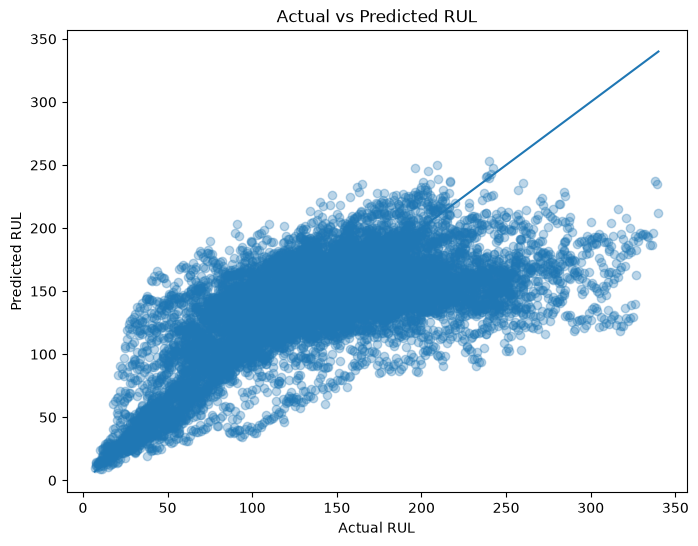

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    test_results["actual_rul"],
    test_results["predicted_rul"],
    alpha=0.3
)

plt.plot(
    [test_results["actual_rul"].min(),
     test_results["actual_rul"].max()],
    [test_results["actual_rul"].min(),
     test_results["actual_rul"].max()]
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

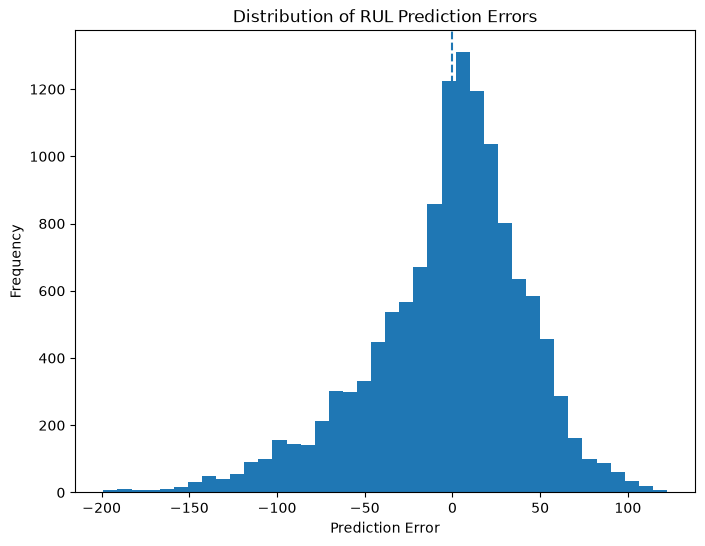

In [197]:
plt.figure(figsize=(8, 6))

plt.hist(
    test_results["error"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of RUL Prediction Errors")

plt.show()

In [198]:
results_summary = pd.DataFrame({
    "model": ["XGBoost"],
    "validation_mae": [np.mean(final_mae_scores)],
    "validation_rmse": [np.mean(final_rmse_scores)],
    "test_mae": [test_mae],
    "test_rmse": [test_rmse]
})

print(results_summary.to_string(index=False))

  model  validation_mae  validation_rmse  test_mae  test_rmse
XGBoost       30.198901        42.122266 33.799995  45.110328


In [199]:
print("Actual RUL:")
print(test_actual_rul.describe())

print("\nPredicted RUL:")
print(pd.Series(test_predictions).describe())

Actual RUL:
count    13096.000000
mean       141.238470
std         58.980114
min          7.000000
25%        102.000000
50%        140.000000
75%        179.000000
max        340.000000
Name: RUL, dtype: float64

Predicted RUL:
count    13096.000000
mean       138.385284
std         38.593140
min          8.698936
25%        124.819637
50%        143.068825
75%        161.917946
max        253.125305
dtype: float64


In [200]:
print("NaN predictions:", np.isnan(test_predictions).sum())
print("Infinite predictions:", np.isinf(test_predictions).sum())

NaN predictions: 0
Infinite predictions: 0
